In [2]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
"The bowler delivered a fast yorker that clean bowled the batsman.",
"The captain set an aggressive field to stop the runs.",
"The batsman scored a brilliant century in the final match.",
"The spinner confused the batsman with a sharp turning delivery.",
"The chef added fresh herbs to enhance the flavor of the soup.",
"Baking a cake requires precise measurements of ingredients.",
"The vegetables were sautéed in olive oil and garlic.",
"Strong passwords help protect online accounts from hackers.",
"A firewall blocks unauthorized access to a computer network.",
"Encryption secures sensitive information during data transmission."
]

embeddings = model.encode(sentences)

e:\massai\codes\python\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1853.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 1.          0.32752866  0.52021015  0.58242214  0.14430304  0.05476635
   0.06765689  0.06045406  0.02679891  0.11712702]
 [ 0.32752866  1.0000006   0.2634016   0.37495667  0.05630479 -0.11634763
  -0.00964011  0.04338678  0.11251139  0.02867031]
 [ 0.52021015  0.2634016   1.0000005   0.5079246   0.00460832  0.09483659
   0.02917153  0.01495232  0.03474041  0.0497517 ]
 [ 0.58242214  0.37495667  0.5079246   1.0000006   0.09962949  0.01555595
   0.05722274 -0.01131691  0.05292856  0.02987644]
 [ 0.14430304  0.05630479  0.00460832  0.09962949  1.0000005   0.13958026
   0.47355205  0.03342072  0.03389053 -0.0547577 ]
 [ 0.05476635 -0.11634763  0.09483659  0.01555595  0.13958026  1.0000004
   0.15543617 -0.02511529 -0.01009501  0.07236895]
 [ 0.06765689 -0.00964011  0.02917153  0.05722274  0.47355205  0.15543617
   1.0000002  -0.05467607 -0.01153307 -0.01671647]
 [ 0.06045406  0.04338678  0.01495232 -0.01131691  0.03342072 -0.02511529
  -0.05467607  1.0000001   0.2364677   0.33906952]
 

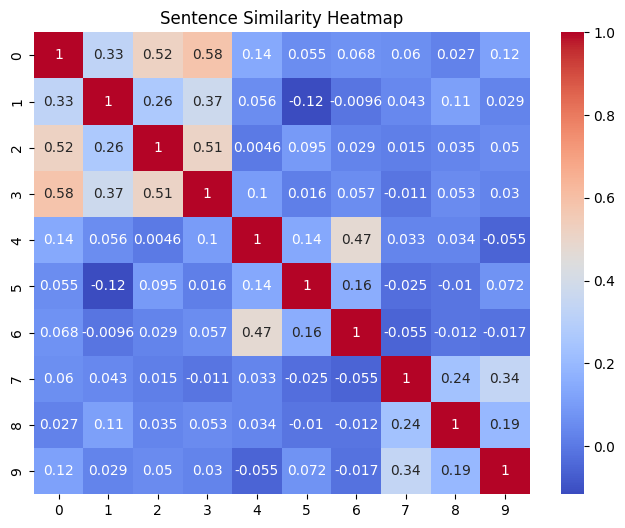

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [8]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

top2_idx = np.argsort(scores)[-2:][::-1]

for idx in top2_idx:
    print(sentences[idx], "-> Similarity:", scores[idx])

The bowler delivered a fast yorker that clean bowled the batsman. -> Similarity: 0.648054
The batsman scored a brilliant century in the final match. -> Similarity: 0.5475372
